# 04-1. PyTorch 학습 진단

현재 MobileNetV3 Small 본학습에서 Train/Validation Accuracy가 약 14%에 머무는 원인을 확인하기 위한 **진단용 노트북**이다.

이 노트북은 본학습을 다시 돌리지 않고 아래 항목만 빠르게 확인한다.

1. grayscale PNG와 JSON 라벨 연결
2. 7개 감정 라벨 분포
3. DataLoader의 이미지 shape / pixel 범위 / label
4. 실제 이미지와 라벨 육안 확인
5. 작은 Batch 하나를 모델이 외울 수 있는지 확인

> 기존 `04_pytorch_model_training.ipynb`는 그대로 보존한다.

## 1. 환경 및 경로 확인

본학습과 같은 프로젝트 경로를 사용하되, 여기서는 진단만 수행한다.

In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("CUDA 사용 가능:", torch.cuda.is_available())
print("사용 장치:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PROJECT_ROOT = Path(r"D:\emotion_recognition_project")

GRAY_TRAIN_DIR = PROJECT_ROOT / "02_data" / "processed" / "grayscale_png" / "train"
GRAY_VALID_DIR = PROJECT_ROOT / "02_data" / "processed" / "grayscale_png" / "valid"

TRAIN_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "train"
VALID_LABEL_DIR = PROJECT_ROOT / "02_data" / "labels" / "valid"

CLASS_NAMES = ["기쁨", "당황", "분노", "불안", "상처", "슬픔", "중립"]
LABEL_TO_IDX = {label: idx for idx, label in enumerate(CLASS_NAMES)}

print("Train 이미지 경로:", GRAY_TRAIN_DIR)
print("Valid 이미지 경로:", GRAY_VALID_DIR)
print("Train 라벨 경로:", TRAIN_LABEL_DIR)
print("Valid 라벨 경로:", VALID_LABEL_DIR)


PyTorch: 2.5.1+cu121
CUDA 사용 가능: True
사용 장치: cuda
GPU: NVIDIA GeForce RTX 3070
Train 이미지 경로: D:\emotion_recognition_project\02_data\processed\grayscale_png\train
Valid 이미지 경로: D:\emotion_recognition_project\02_data\processed\grayscale_png\valid
Train 라벨 경로: D:\emotion_recognition_project\02_data\labels\train
Valid 라벨 경로: D:\emotion_recognition_project\02_data\labels\valid


## 2. 이미지와 라벨 연결 상태 확인

본학습과 같은 방식으로 grayscale PNG와 JSON의 `filename`을 연결한다.  
학습 라벨은 `faceExp_uploader`를 사용한다.

Training 223,578건 / Validation 52,126건이 정확히 나오는지 다시 확인한다.

In [2]:
def build_dataframe(image_dir, label_dir):
    image_map = {path.stem: path for path in image_dir.glob("*.png")}
    records = []

    for json_path in sorted(label_dir.rglob("*.json")):
        with open(json_path, "r", encoding="utf-8") as f:
            label_data = json.load(f)

        for record in label_data:
            original_name = record["filename"]
            stem = Path(original_name).stem
            label = record["faceExp_uploader"]

            if stem in image_map and label in LABEL_TO_IDX:
                records.append({
                    "filename": original_name,
                    "image_path": str(image_map[stem]),
                    "label": label,
                    "label_index": LABEL_TO_IDX[label],
                })

    return pd.DataFrame(records)


train_df = build_dataframe(GRAY_TRAIN_DIR, TRAIN_LABEL_DIR)
valid_df = build_dataframe(GRAY_VALID_DIR, VALID_LABEL_DIR)

print("Training 연결 수:", len(train_df))
print("Validation 연결 수:", len(valid_df))

assert len(train_df) == 223578, f"Training 수가 예상과 다릅니다: {len(train_df)}"
assert len(valid_df) == 52126, f"Validation 수가 예상과 다릅니다: {len(valid_df)}"

display(train_df.head(10))


Training 연결 수: 223578
Validation 연결 수: 52126


,filename,image_path,label,label_index
0,5f656a0f627a3ef96dec882437e3e7ada1c7a877201cf5...,D:\emotion_recognition_project\02_data\process...,기쁨,0
1,92e7098109470430238876b447f55a978adf237c93b438...,D:\emotion_recognition_project\02_data\process...,기쁨,0
2,5a30dc193e2c6144184968043c00773270b111a23a3c83...,D:\emotion_recognition_project\02_data\process...,기쁨,0
3,29b5343b8eca7460aea95cd18db40b015a58ec4db64b71...,D:\emotion_recognition_project\02_data\process...,기쁨,0
4,4e91bb1317ff7616b99cadf3cafaf8dab49bc6985a0367...,D:\emotion_recognition_project\02_data\process...,기쁨,0
5,9dbc66073c47d92f7d9f79f355985d3ac03d6ccf0dc3dc...,D:\emotion_recognition_project\02_data\process...,기쁨,0
6,6cb613add377a52ee07320929fa4a5b7d7398ce91bca45...,D:\emotion_recognition_project\02_data\process...,기쁨,0
7,7f502f7249c1d10025fdb04ae710574a813ef0199d4c23...,D:\emotion_recognition_project\02_data\process...,기쁨,0
8,961b92c8462e23caf4b7721aa9b82ecbb344624b21ac16...,D:\emotion_recognition_project\02_data\process...,기쁨,0
9,9e0d92ef0f578026938d62634efe9407566ded1d249ad6...,D:\emotion_recognition_project\02_data\process...,기쁨,0


### 2-1. 라벨 분포와 label_index 확인

7개 감정이 모두 존재하는지, `label`과 `label_index`가 정확히 연결되는지 확인한다.

In [3]:
print("Training 감정별 개수")
display(train_df["label"].value_counts().reindex(CLASS_NAMES))

print("\nValidation 감정별 개수")
display(valid_df["label"].value_counts().reindex(CLASS_NAMES))

print("\nTraining label_index 종류:", sorted(train_df["label_index"].unique()))
print("Validation label_index 종류:", sorted(valid_df["label_index"].unique()))

print("\nlabel ↔ index 매핑")
display(
    train_df[["label", "label_index"]]
    .drop_duplicates()
    .sort_values("label_index")
)


Training 감정별 개수


label
기쁨    31986
당황    32094
분노    32114
불안    32046
상처    31529
슬픔    31678
중립    32131
Name: count, dtype: int64


Validation 감정별 개수


label
기쁨    7499
당황    7454
분노    7461
불안    7407
상처    7423
슬픔    7479
중립    7403
Name: count, dtype: int64


Training label_index 종류: [0, 1, 2, 3, 4, 5, 6]
Validation label_index 종류: [0, 1, 2, 3, 4, 5, 6]

label ↔ index 매핑


,label,label_index
0,기쁨,0
31986,당황,1
64080,분노,2
96194,불안,3
128240,상처,4
159769,슬픔,5
191447,중립,6


## 3. Dataset / DataLoader 출력 확인

본학습과 같은 입력 방식을 사용해 한 Batch만 꺼내 확인한다.

In [4]:
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
])


class EmotionDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        with Image.open(row["image_path"]) as img:
            image = img.convert("L")

        if self.transform:
            image = self.transform(image)

        label = int(row["label_index"])
        return image, label


train_dataset = EmotionDataset(train_df, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
)

images, labels = next(iter(train_loader))

print("images.shape:", images.shape)
print("labels.shape:", labels.shape)
print("pixel min:", images.min().item())
print("pixel max:", images.max().item())
print("pixel mean:", images.mean().item())
print("labels:", labels)
print("Batch 라벨별 개수:", torch.bincount(labels, minlength=7))

channel_diff_01 = (images[:, 0] - images[:, 1]).abs().max().item()
channel_diff_12 = (images[:, 1] - images[:, 2]).abs().max().item()

print("채널 0-1 최대 차이:", channel_diff_01)
print("채널 1-2 최대 차이:", channel_diff_12)


images.shape: torch.Size([32, 3, 224, 224])
labels.shape: torch.Size([32])
pixel min: 0.0
pixel max: 1.0
pixel mean: 0.490896612405777
labels: tensor([2, 0, 6, 4, 2, 1, 4, 3, 5, 4, 2, 6, 2, 3, 2, 4, 2, 6, 6, 6, 6, 4, 6, 2,
        1, 3, 4, 0, 1, 5, 3, 0])
Batch 라벨별 개수: tensor([3, 3, 7, 4, 6, 2, 7])
채널 0-1 최대 차이: 0.0
채널 1-2 최대 차이: 0.0


### 정상 기준

- `images.shape` → `[32, 3, 224, 224]`
- pixel 범위 → 대체로 `0.0 ~ 1.0`
- labels → 0~6 중 여러 값이 섞여 있음
- 채널 간 최대 차이 → `0.0`에 가까움

## 4. 실제 이미지와 라벨 눈으로 확인

랜덤 샘플 12장을 띄우고, 각 이미지 위에 `faceExp_uploader` 라벨을 표시한다.

C:\Users\USER\AppData\Local\Temp\ipykernel_66292\3635177166.py:13: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_66292\3635177166.py:13: UserWarning: Glyph 54548 (\N{HANGUL SYLLABLE PEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_66292\3635177166.py:13: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_66292\3635177166.py:13: UserWarning: Glyph 49256 (\N{HANGUL SYLLABLE BBEUM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_66292\3635177166.py:13: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\USER\AppData\Local\Temp\ipykernel_66292\3635177166.py:13: UserWarning: Glyph 47549 (\N{HANGUL SYLLABLE RIB}) missing from 

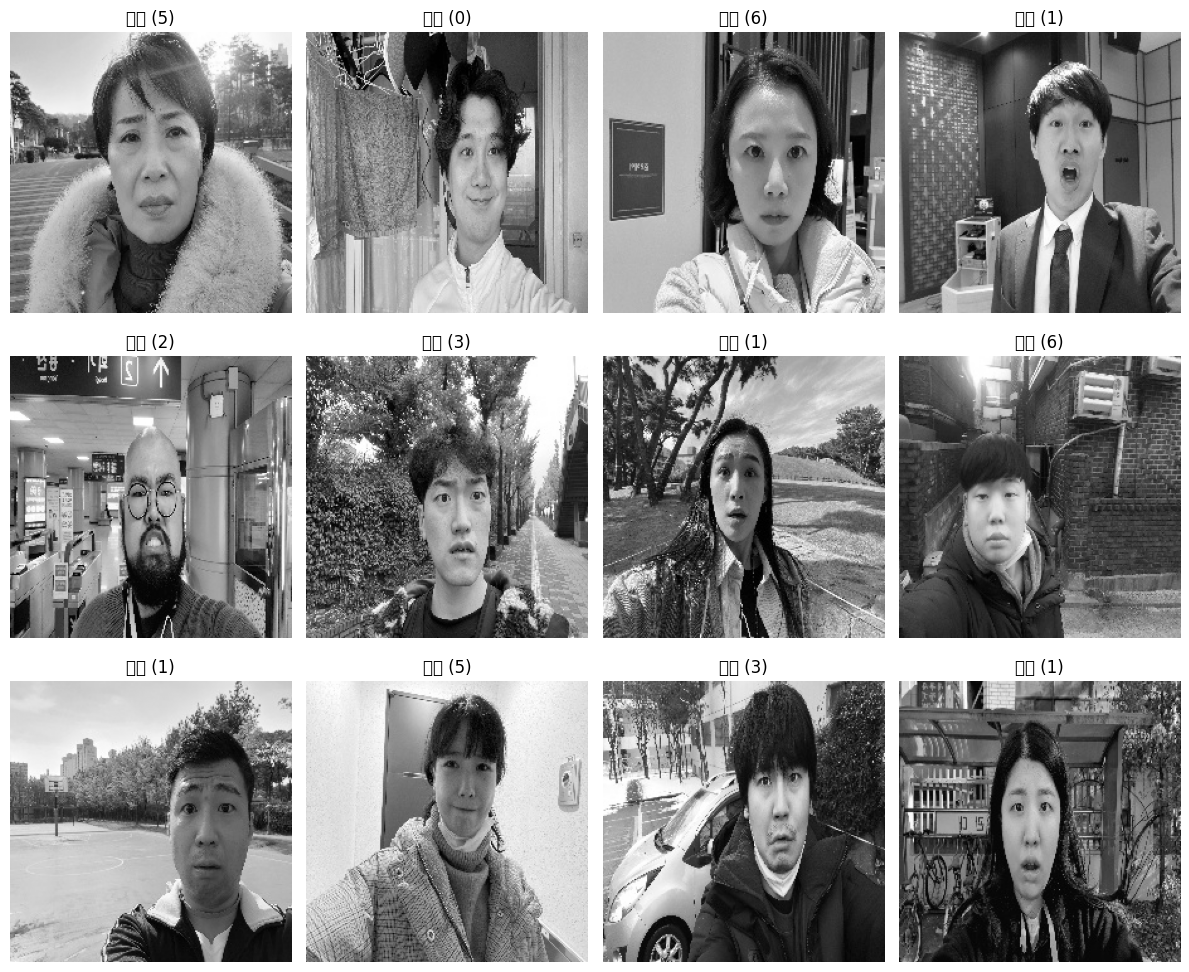

,filename,label,label_index,image_path
0,1bdf8aa7d5f27a0f17ba1b46bf2fcfcd3d2bdd296b3c24...,슬픔,5,D:\emotion_recognition_project\02_data\process...
1,0de90b7d70454e372b6ed56bdfdba5a10c1036514f6093...,기쁨,0,D:\emotion_recognition_project\02_data\process...
2,478b7927e1e55c0fb029e03f5b703a07200b551c7d7ad6...,중립,6,D:\emotion_recognition_project\02_data\process...
3,21ee461934c5f88f24993d031484c617fb911a03ead847...,당황,1,D:\emotion_recognition_project\02_data\process...
4,05e87fd9e81d424f73152d9701e956e7738fcab18a5dec...,분노,2,D:\emotion_recognition_project\02_data\process...
5,78d03c9f05cd1e85ff843217b18f283c30ef6182889321...,불안,3,D:\emotion_recognition_project\02_data\process...
6,8d08e1acf6ef589b06970e3d5ec78444fd26c9adf4382a...,당황,1,D:\emotion_recognition_project\02_data\process...
7,584a618920ff2090c7922dbb32eb430e37073742676724...,중립,6,D:\emotion_recognition_project\02_data\process...
8,3fd10befe08024d2bac782beec621aad2a7f6f467ba233...,당황,1,D:\emotion_recognition_project\02_data\process...
9,22f17e41dedf8cb19d76cae91e9bbb090c8b1161c71677...,슬픔,5,D:\emotion_recognition_project\02_data\process...


In [5]:
sample_df = train_df.sample(n=12, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(12, 10))

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    with Image.open(row["image_path"]) as img:
        image = img.convert("L")

    ax.imshow(image, cmap="gray")
    ax.set_title(f'{row["label"]} ({row["label_index"]})')
    ax.axis("off")

plt.tight_layout()
plt.show()

display(sample_df[["filename", "label", "label_index", "image_path"]])


## 5. 작은 Batch 과적합 테스트

전체 데이터 문제인지, 모델/학습 코드 문제인지 빠르게 구분하기 위한 진단이다.

같은 Batch 32장만 반복해서 학습시킨다.  
정상적인 학습 코드라면 Loss가 내려가고 Accuracy가 올라가는 방향이 나타나야 한다.

> 이 테스트는 본학습 결과가 아니라 원인 확인용이다.

In [6]:
def create_debug_model(num_classes=7):
    model = models.mobilenet_v3_small(weights=None)
    model.classifier[3] = nn.Linear(
        model.classifier[3].in_features,
        num_classes,
    )
    return model


debug_images = images.to(device)
debug_labels = labels.to(device)

debug_model = create_debug_model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(debug_model.parameters(), lr=0.001)

print("작은 Batch 과적합 테스트 시작")

for step in range(1, 31):
    debug_model.train()
    optimizer.zero_grad()

    outputs = debug_model(debug_images)
    loss = criterion(outputs, debug_labels)

    loss.backward()
    optimizer.step()

    predictions = outputs.argmax(dim=1)
    accuracy = (predictions == debug_labels).float().mean().item()

    if step == 1 or step % 5 == 0:
        print(
            f"Step {step:02d} | "
            f"loss={loss.item():.4f} | "
            f"accuracy={accuracy:.4f}"
        )


작은 Batch 과적합 테스트 시작
Step 01 | loss=1.9473 | accuracy=0.1875
Step 05 | loss=1.1871 | accuracy=0.6250
Step 10 | loss=0.2458 | accuracy=0.8750
Step 15 | loss=0.0384 | accuracy=1.0000
Step 20 | loss=0.0013 | accuracy=1.0000
Step 25 | loss=0.0004 | accuracy=1.0000
Step 30 | loss=0.0002 | accuracy=1.0000


## 6. 진단 결과 판단 기준

1. Train = 223,578 / Validation = 52,126인가?
2. 7개 감정과 label_index 0~6이 모두 존재하는가?
3. 입력 Tensor가 `[32, 3, 224, 224]`, pixel 약 0~1인가?
4. 실제 이미지와 표시된 감정 라벨 연결이 이상하지 않은가?
5. 작은 Batch 과적합 테스트에서 Loss가 내려가고 Accuracy가 올라가는가?

이 다섯 가지 결과를 확인한 뒤 본학습 재개 여부를 결정한다.